Download the dataset

In [9]:
!mkdir -p ~/.kaggle
!echo "KGAT_125e5089828e6530ceea575c217c8586" > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

In [10]:
!kaggle datasets download -d pratik2901/multiclass-weather-dataset

Dataset URL: https://www.kaggle.com/datasets/pratik2901/multiclass-weather-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 91.4M/91.4M [00:00<00:00, 101MB/s]



In [11]:
!unzip -q multiclass-weather-dataset.zip -d ./weather_data

In [12]:
import os
if os.path.exists('multiclass-weather-dataset.zip'):
    os.remove('multiclass-weather-dataset.zip')

print("Success! Data downloaded and unzipped directly into Colab without files!")

Success! Data downloaded and unzipped directly into Colab without files!


In [5]:
import tensorflow as tf
from tensorflow import keras
from keras.preprocessing.image import load_img,img_to_array
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


In [13]:
DATA_PATH = "/content/weather_data/Multi-class Weather Dataset"
IMG_SIZE = (150,150)
BATCH_SIZE = 32

In [14]:
#Load the training data
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 1125 files belonging to 4 classes.
Using 900 files for training.


In [15]:
# Load validation split (20%)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 1125 files belonging to 4 classes.
Using 225 files for validation.


In [16]:
class_names = train_ds.class_names
class_names

['Cloudy', 'Rain', 'Shine', 'Sunrise']

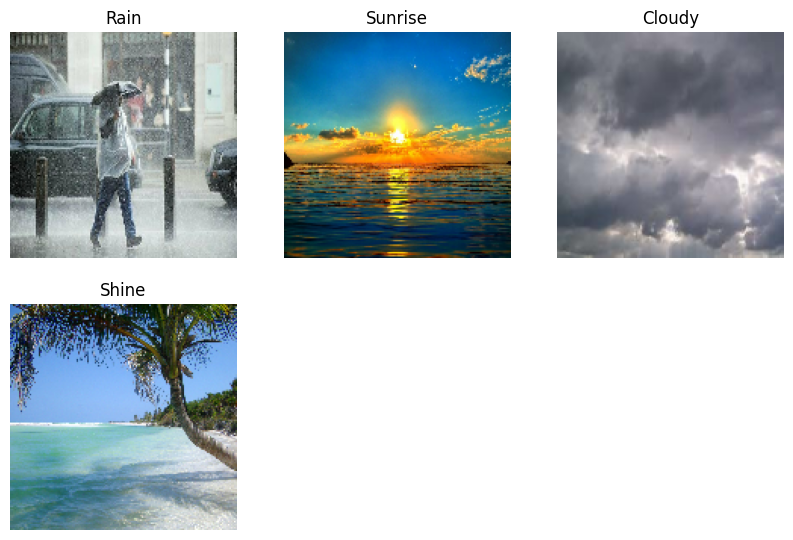

In [11]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(5):

    for i in range(4):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

Model Training

In [ ]:
model = models.Sequential([
    
    layers.Rescaling(1./255, input_shape=(150, 150, 3)),

    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])


model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,868 (18.42 MB)

 Trainable params: 4,828,868 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 250ms/step - accuracy: 0.5600 - loss: 1.0764 - val_accuracy: 0.7644 - val_loss: 0.6548
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.8044 - loss: 0.5833 - val_accuracy: 0.8133 - val_loss: 0.4593
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.8567 - loss: 0.4089 - val_accuracy: 0.8133 - val_loss: 0.5261
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.8300 - loss: 0.4967 - val_accuracy: 0.7156 - val_loss: 0.7836
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - accuracy: 0.8444 - loss: 0.4228 - val_accuracy: 0.8844 - val_loss: 0.3757
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.8867 - loss: 0.3251 - val_accuracy: 0.9022 - val_loss: 0.2884
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.9100 - loss: 0.2548 - val_accuracy: 0.8711 - val_loss: 0.3762
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.8967 - loss: 0.2869 - val_accuracy: 0.8800 

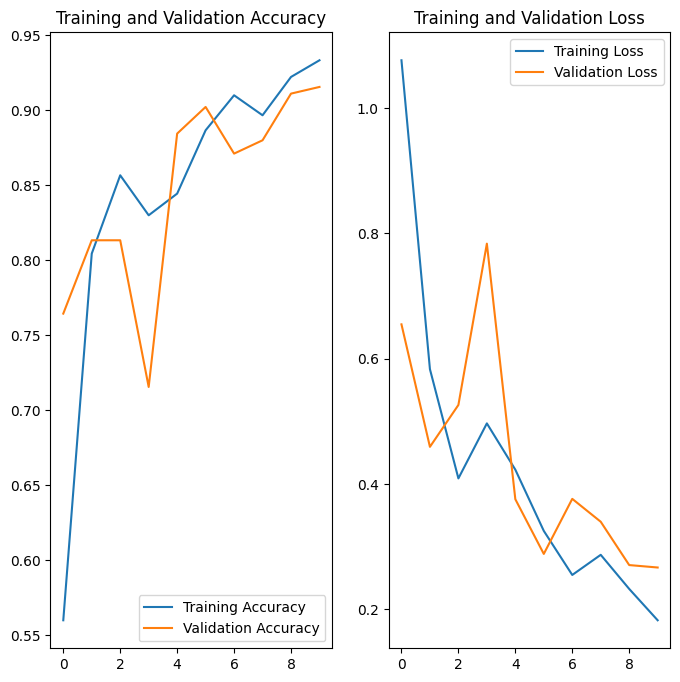

In [20]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [21]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
])

In [ ]:
model2 = models.Sequential([

    layers.Input(shape=(150, 150, 3)),
    data_augmentation,

    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),

    
    layers.Dropout(0.5),

    layers.Dense(len(class_names), activation='softmax')
])


model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,847,748 (7.05 MB)

 Trainable params: 1,847,748 (7.05 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
epochs2 = 30
history2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs2
)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.5033 - loss: 1.0057 - val_accuracy: 0.5333 - val_loss: 0.8168
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - accuracy: 0.6222 - loss: 0.7861 - val_accuracy: 0.6711 - val_loss: 0.7403
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.7078 - loss: 0.6551 - val_accuracy: 0.7689 - val_loss: 0.5677
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.7522 - loss: 0.5814 - val_accuracy: 0.7467 - val_loss: 0.5427
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step - accuracy: 0.7856 - loss: 0.4940 - val_accuracy: 0.8089 - val_loss: 0.4552
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.8111 - loss: 0.4772 - val_accuracy: 0.7467 - val_loss: 0.9342
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.8056 - loss: 0.4867 - val_accuracy: 0.8133 - val_loss: 0.5070
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - accuracy: 0.7900 - loss: 0.5297 - val_accuracy: 0.8044 - 

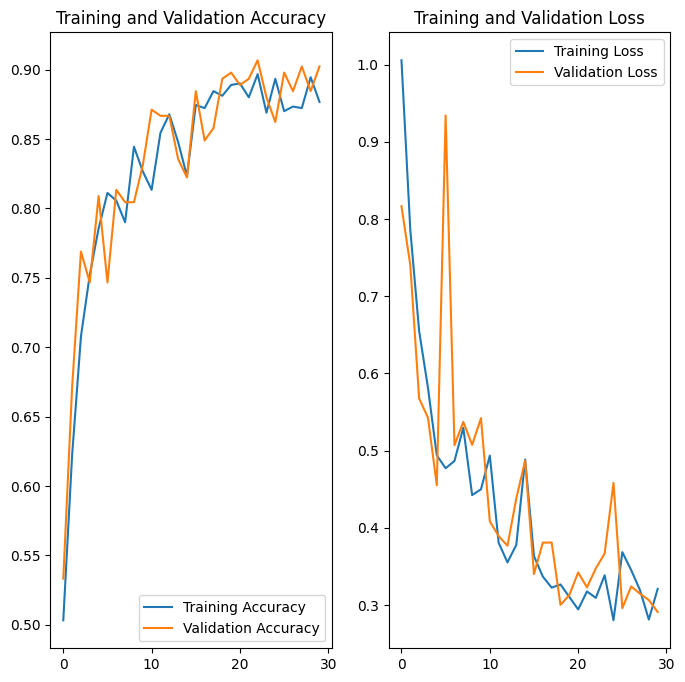

In [24]:
acc = history2.history['accuracy']
val_acc = history2.history['val_accuracy']

loss = history2.history['loss']
val_loss = history2.history['val_loss']

epochs_range = range(epochs2)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [25]:
model2.save('weather_cnn_model.h5')

In [31]:
model2.save_weights('weather_cnn.weights.h5')

Testing

In [26]:
test_image_url = "https://images.unsplash.com/photo-1534274988757-a28bf1a57c17?w=500"
image_path = tf.keras.utils.get_file('test_image.jpg', origin=test_image_url)

In [27]:
img = tf.keras.utils.load_img(image_path, target_size=(150, 150))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

In [28]:
loaded_model = tf.keras.models.load_model('weather_cnn_model.h5')
predictions = loaded_model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


In [29]:
predicted_class = class_names[np.argmax(predictions)]
predicted_class

'Rain'